### PathVQA Data Analysis

This code will analyze raw PathVQA data and find how much data was filtered based on non-pathology images as well as containing less number of words

In [1]:
import sys
from PIL import Image
import pandas as pd
import os
import pickle
from collections import Counter
import numpy as np
import shutil
import seaborn as sns
import matplotlib.pyplot as plt

#### Raw Data Paths

In [2]:
pvqa_data_path = "/data/mn27889/pvqa"
pvqa_images = os.path.join(pvqa_data_path, "images")
pvqa_qas = os.path.join(pvqa_data_path, "qas")

#### Paths of PathVQA images after filtering down the histopathology images

In [3]:
pvqa_histo_data_path = "/data/mn27889/path-open-data/pathvqa-histopathology"
pvqa_histo_images = os.path.join(pvqa_histo_data_path, "images")
pvqa_histo_qas = os.path.join(pvqa_histo_data_path, "qas")

#### 1. Analyzing the images/qas from `train` subset

In [4]:
pvqa_subset = "train"
qas_filename = f"{pvqa_subset}_qa.pkl"

##### Raw

In [5]:
pvqa_images_subset_path = os.path.join(pvqa_images, pvqa_subset)
pvqa_qas_subset_path = os.path.join(pvqa_qas, pvqa_subset)

pvqa_image_list = os.listdir(pvqa_images_subset_path)
print(f"Number of images in Raw {pvqa_subset} subset: {len(pvqa_image_list)}")

qas_file_path = os.path.join(pvqa_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_qas_subset = pickle.load(file)

print(f'Total Raw {pvqa_subset} Samples:',len(pvqa_qas_subset))

pvqa_qas_close_ended = [sample for sample in pvqa_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_qas_open_ended = [sample for sample in pvqa_qas_subset if sample not in pvqa_qas_close_ended]

print(f'Number of Raw {pvqa_subset} Close-Ended Questions:', len(pvqa_qas_close_ended))
print(f'Number of Raw {pvqa_subset} Open-Ended Questions:', len(pvqa_qas_open_ended))

pvqa_valid_close_ended_samples = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_valid_open_ended_samples = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]
print(f'Number of Valid {pvqa_subset} Close-Ended Questions:', len(pvqa_valid_close_ended_samples))
print(f'Number of Valid {pvqa_subset} Open-Ended Questions:', len(pvqa_valid_open_ended_samples))

pvqa_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_valid_open_ended_samples]
counts = Counter(pvqa_ques_first_word)
print(f"First Word in Raw {pvqa_subset} Open-Ended Questions: ", counts)

Number of images in Raw train subset: 3021
Total Raw train Samples: 19755
Number of Raw train Close-Ended Questions: 9806
Number of Raw train Open-Ended Questions: 9949
Number of Valid train Close-Ended Questions: 5913
Number of Valid train Open-Ended Questions: 1321
First Word in Raw train Open-Ended Questions:  Counter({'what': 1155, 'how': 108, 'why': 36, 'where': 15, 'when': 7})


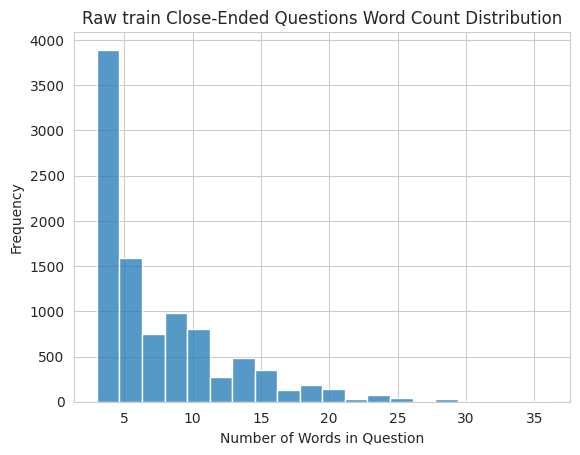

In [6]:
pvqa_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_close_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


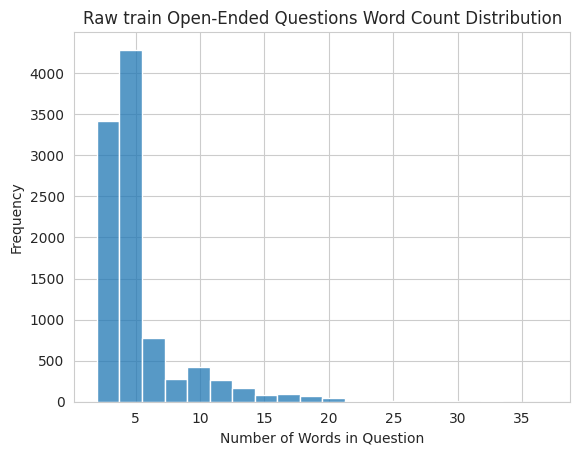

In [7]:
pvqa_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

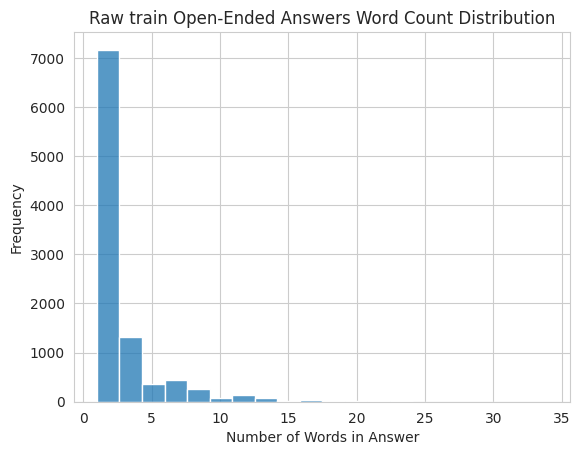

In [8]:
pvqa_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_answers_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

##### Histo

In [9]:
pvqa_histo_images_subset_path = os.path.join(pvqa_histo_images, pvqa_subset)
pvqa_histo_qas_subset_path = os.path.join(pvqa_histo_qas, pvqa_subset)

pvqa_histo_image_list = os.listdir(pvqa_histo_images_subset_path)
print(f"Number of images in Histo {pvqa_subset} subset: {len(pvqa_histo_image_list)}")

qas_file_path = os.path.join(pvqa_histo_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_histo_qas_subset = pickle.load(file)

print(f'Total Histo {pvqa_subset} Samples:',len(pvqa_histo_qas_subset))

pvqa_histo_qas_close_ended = [sample for sample in pvqa_histo_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_histo_qas_open_ended = [sample for sample in pvqa_histo_qas_subset if sample not in pvqa_histo_qas_close_ended]

print(f'Number of Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_qas_close_ended))
print(f'Number of Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_qas_open_ended))

pvqa_histo_valid_close_ended_samples = [sample for sample in pvqa_histo_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_histo_valid_open_ended_samples = [sample for sample in pvqa_histo_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]

print(f'Number of Valid Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_valid_close_ended_samples))
print(f'Number of Valid Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_valid_open_ended_samples))

pvqa_histo_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_histo_valid_open_ended_samples]
counts = Counter(pvqa_histo_ques_first_word)
print(f'First Word in Histo {pvqa_subset} Open-Ended Questions: ', counts)

Number of images in Histo train subset: 896
Total Histo train Samples: 5395
Number of Histo train Close-Ended Questions: 2751
Number of Histo train Open-Ended Questions: 2644
Number of Valid Histo train Close-Ended Questions: 1785
Number of Valid Histo train Open-Ended Questions: 378
First Word in Histo train Open-Ended Questions:  Counter({'what': 325, 'how': 36, 'why': 9, 'where': 7, 'when': 1})


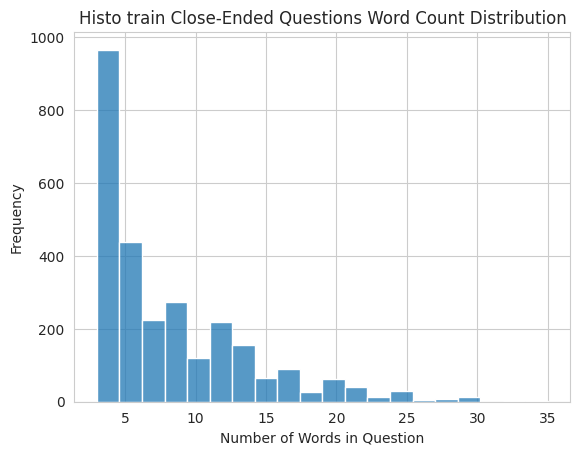

In [10]:
pvqa_histo_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_close_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


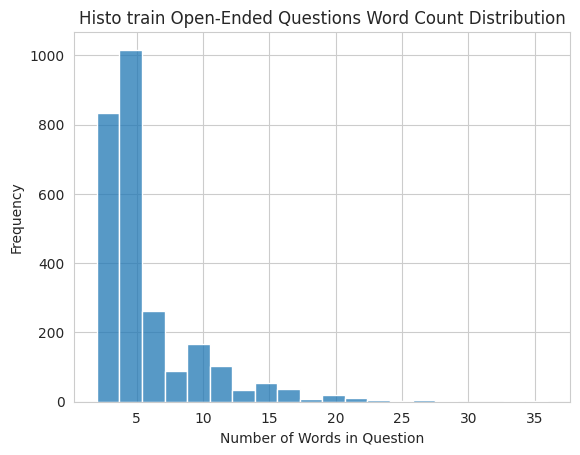

In [11]:
pvqa_histo_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

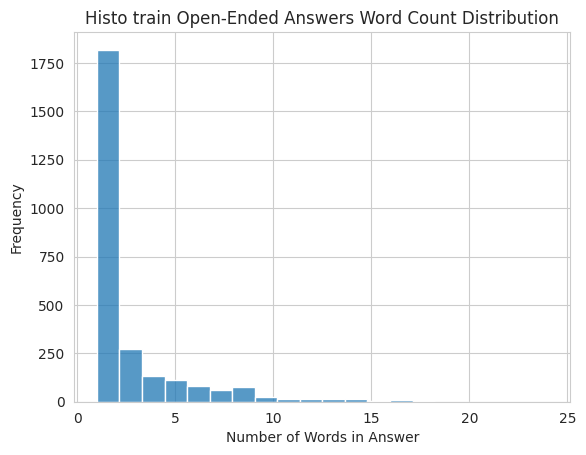

In [12]:
pvqa_histo_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_answers_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

#### 2. Analyzing the images/qas from `test` subset

In [ ]:
pvqa_subset = "test"
qas_filename = f"{pvqa_subset}_qa.pkl"

##### Raw

In [ ]:
pvqa_images_subset_path = os.path.join(pvqa_images, pvqa_subset)
pvqa_qas_subset_path = os.path.join(pvqa_qas, pvqa_subset)

pvqa_image_list = os.listdir(pvqa_images_subset_path)
print(f"Number of images in Raw {pvqa_subset} subset: {len(pvqa_image_list)}")

qas_file_path = os.path.join(pvqa_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_qas_subset = pickle.load(file)

print(f'Total Raw {pvqa_subset} Samples:',len(pvqa_qas_subset))

pvqa_qas_close_ended = [sample for sample in pvqa_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_qas_open_ended = [sample for sample in pvqa_qas_subset if sample not in pvqa_qas_close_ended]

print(f'Number of Raw {pvqa_subset} Close-Ended Questions:', len(pvqa_qas_close_ended))
print(f'Number of Raw {pvqa_subset} Open-Ended Questions:', len(pvqa_qas_open_ended))

pvqa_valid_close_ended_samples = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_valid_open_ended_samples = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]
print(f'Number of Valid {pvqa_subset} Close-Ended Questions:', len(pvqa_valid_close_ended_samples))
print(f'Number of Valid {pvqa_subset} Open-Ended Questions:', len(pvqa_valid_open_ended_samples))

pvqa_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_valid_open_ended_samples]
counts = Counter(pvqa_ques_first_word)
print(f"First Word in Raw {pvqa_subset} Open-Ended Questions: ", counts)

Number of images in Raw test subset: 991
Total Raw test Samples: 6761
Number of Raw test Close-Ended Questions: 3391
Number of Raw test Open-Ended Questions: 3370
Number of Valid test Close-Ended Questions: 2037
Number of Valid test Open-Ended Questions: 438
First Word in Raw test Open-Ended Questions:  Counter({'what': 387, 'how': 27, 'why': 13, 'where': 5, 'when': 4, 'under': 1, 'by': 1})


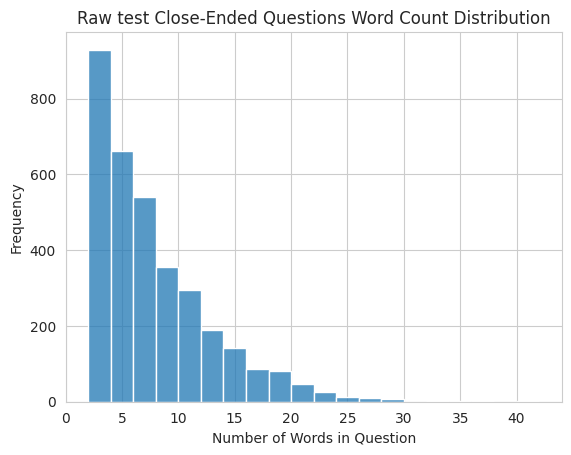

In [ ]:
pvqa_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_close_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


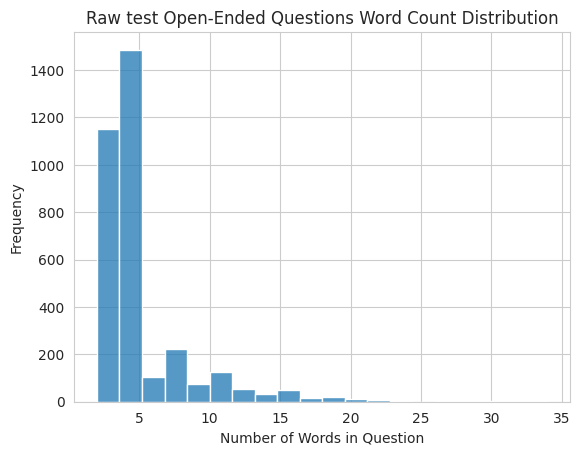

In [ ]:
pvqa_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

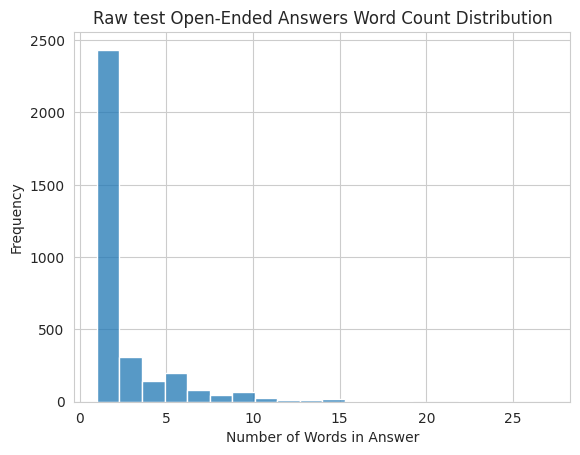

In [ ]:
pvqa_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_answers_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

##### Histo

In [ ]:
pvqa_histo_images_subset_path = os.path.join(pvqa_histo_images, pvqa_subset)
pvqa_histo_qas_subset_path = os.path.join(pvqa_histo_qas, pvqa_subset)

pvqa_histo_image_list = os.listdir(pvqa_histo_images_subset_path)
print(f"Number of images in Histo {pvqa_subset} subset: {len(pvqa_histo_image_list)}")

qas_file_path = os.path.join(pvqa_histo_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_histo_qas_subset = pickle.load(file)

print(f'Total Histo {pvqa_subset} Samples:',len(pvqa_histo_qas_subset))

pvqa_histo_qas_close_ended = [sample for sample in pvqa_histo_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_histo_qas_open_ended = [sample for sample in pvqa_histo_qas_subset if sample not in pvqa_histo_qas_close_ended]

print(f'Number of Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_qas_close_ended))
print(f'Number of Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_qas_open_ended))

pvqa_histo_valid_close_ended_samples = [sample for sample in pvqa_histo_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_histo_valid_open_ended_samples = [sample for sample in pvqa_histo_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]

print(f'Number of Valid Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_valid_close_ended_samples))
print(f'Number of Valid Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_valid_open_ended_samples))

pvqa_histo_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_histo_valid_open_ended_samples]
counts = Counter(pvqa_histo_ques_first_word)
print(f'First Word in Histo {pvqa_subset} Open-Ended Questions: ', counts)

Number of images in Histo test subset: 309
Total Histo test Samples: 1885
Number of Histo test Close-Ended Questions: 995
Number of Histo test Open-Ended Questions: 890
Number of Valid Histo test Close-Ended Questions: 640
Number of Valid Histo test Open-Ended Questions: 117
First Word in Histo test Open-Ended Questions:  Counter({'what': 98, 'how': 13, 'where': 3, 'why': 3})


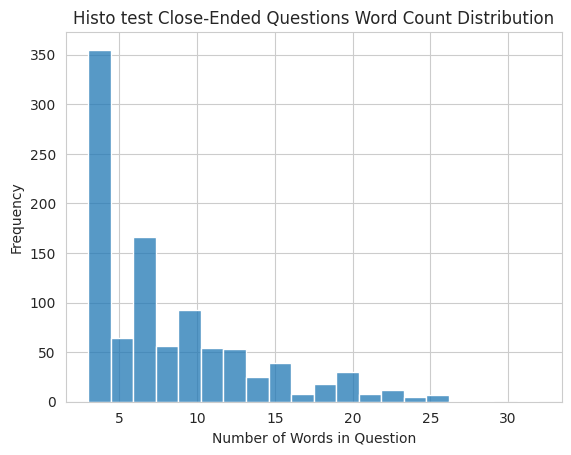

In [ ]:
pvqa_histo_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_close_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


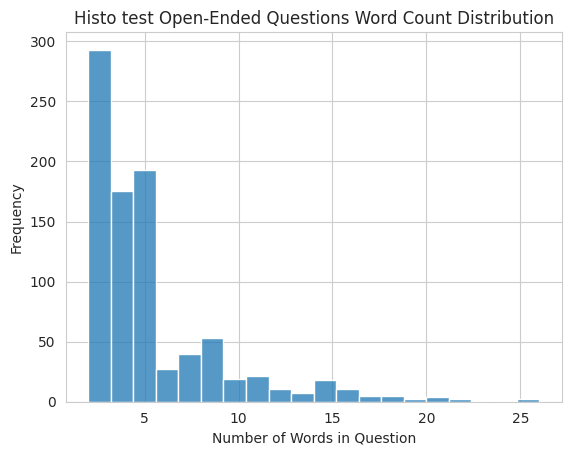

In [ ]:
pvqa_histo_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

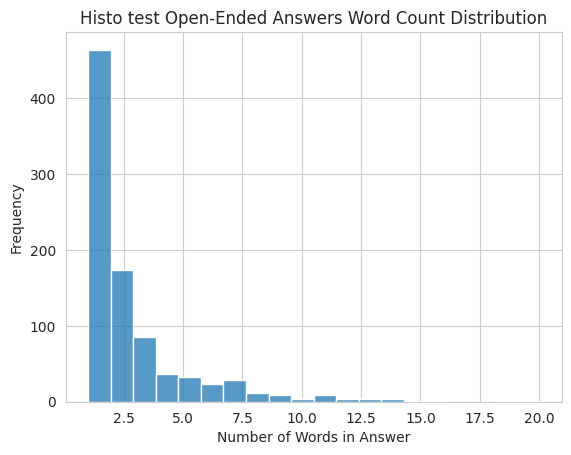

In [ ]:
pvqa_histo_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_answers_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

#### 3. Analyzing the images/qas from `val` subset

In [22]:
pvqa_subset = "val"
qas_filename = f"{pvqa_subset}_qa.pkl"

##### Raw

In [23]:
pvqa_images_subset_path = os.path.join(pvqa_images, pvqa_subset)
pvqa_qas_subset_path = os.path.join(pvqa_qas, pvqa_subset)

pvqa_image_list = os.listdir(pvqa_images_subset_path)
print(f"Number of images in Raw {pvqa_subset} subset: {len(pvqa_image_list)}")

qas_file_path = os.path.join(pvqa_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_qas_subset = pickle.load(file)

print(f'Total Raw {pvqa_subset} Samples:',len(pvqa_qas_subset))

pvqa_qas_close_ended = [sample for sample in pvqa_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_qas_open_ended = [sample for sample in pvqa_qas_subset if sample not in pvqa_qas_close_ended]

print(f'Number of Raw {pvqa_subset} Close-Ended Questions:', len(pvqa_qas_close_ended))
print(f'Number of Raw {pvqa_subset} Open-Ended Questions:', len(pvqa_qas_open_ended))

pvqa_valid_close_ended_samples = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_valid_open_ended_samples = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]
print(f'Number of Valid {pvqa_subset} Close-Ended Questions:', len(pvqa_valid_close_ended_samples))
print(f'Number of Valid {pvqa_subset} Open-Ended Questions:', len(pvqa_valid_open_ended_samples))

pvqa_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_valid_open_ended_samples]
counts = Counter(pvqa_ques_first_word)
print(f"First Word in Raw {pvqa_subset} Open-Ended Questions: ", counts)

Number of images in Raw val subset: 992
Total Raw val Samples: 6279


Number of Raw val Close-Ended Questions: 3135
Number of Raw val Open-Ended Questions: 3144
Number of Valid val Close-Ended Questions: 1896
Number of Valid val Open-Ended Questions: 405
First Word in Raw val Open-Ended Questions:  Counter({'what': 349, 'how': 32, 'why': 11, 'where': 9, 'when': 4})


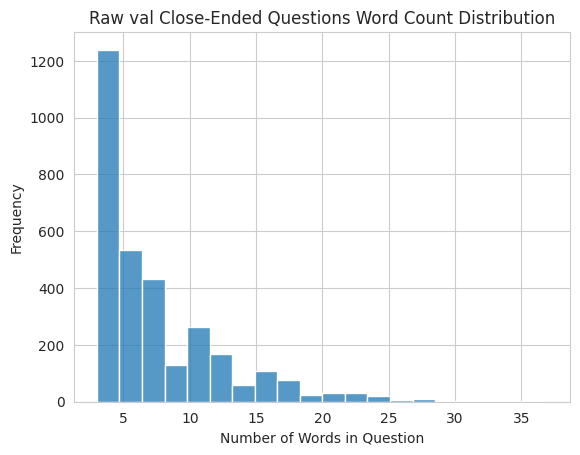

In [24]:
pvqa_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_close_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


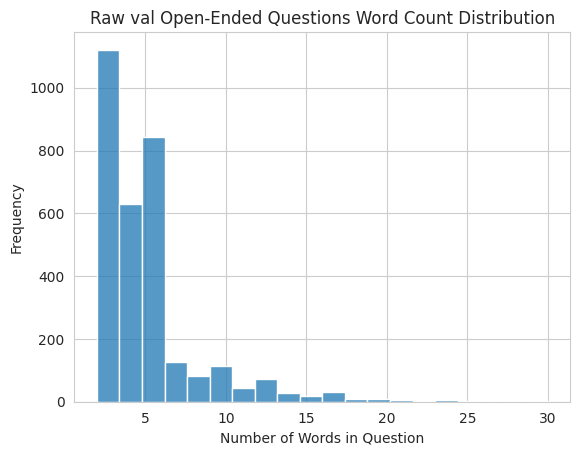

In [25]:
pvqa_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_questions_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

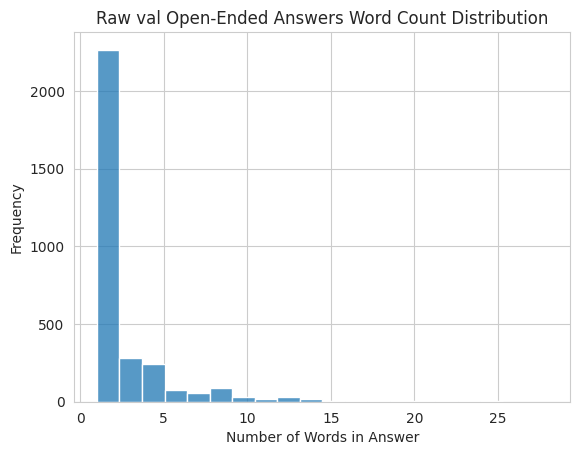

In [26]:
pvqa_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_answers_words_distrib, bins=20)
plt.title(f'Raw {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

##### Histo

In [27]:
pvqa_histo_images_subset_path = os.path.join(pvqa_histo_images, pvqa_subset)
pvqa_histo_qas_subset_path = os.path.join(pvqa_histo_qas, pvqa_subset)

pvqa_histo_image_list = os.listdir(pvqa_histo_images_subset_path)
print(f"Number of images in Histo {pvqa_subset} subset: {len(pvqa_histo_image_list)}")

qas_file_path = os.path.join(pvqa_histo_qas_subset_path, qas_filename)
with open(qas_file_path, 'rb') as file:
    pvqa_histo_qas_subset = pickle.load(file)

print(f'Total Histo {pvqa_subset} Samples:',len(pvqa_histo_qas_subset))

pvqa_histo_qas_close_ended = [sample for sample in pvqa_histo_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
pvqa_histo_qas_open_ended = [sample for sample in pvqa_histo_qas_subset if sample not in pvqa_histo_qas_close_ended]

print(f'Number of Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_qas_close_ended))
print(f'Number of Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_qas_open_ended))

pvqa_histo_valid_close_ended_samples = [sample for sample in pvqa_histo_qas_close_ended if len(sample['question'].split()) >= 5]
pvqa_histo_valid_open_ended_samples = [sample for sample in pvqa_histo_qas_open_ended if len(sample['question'].split()) >= 5 and len(sample['answer'].split()) >= 5]

print(f'Number of Valid Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_histo_valid_close_ended_samples))
print(f'Number of Valid Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_histo_valid_open_ended_samples))

pvqa_histo_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_histo_valid_open_ended_samples]
counts = Counter(pvqa_histo_ques_first_word)
print(f'First Word in Histo {pvqa_subset} Open-Ended Questions: ', counts)

Number of images in Histo val subset: 299
Total Histo val Samples: 1712
Number of Histo val Close-Ended Questions: 884
Number of Histo val Open-Ended Questions: 828
Number of Valid Histo val Close-Ended Questions: 580
Number of Valid Histo val Open-Ended Questions: 117
First Word in Histo val Open-Ended Questions:  Counter({'what': 105, 'how': 7, 'where': 3, 'why': 2})


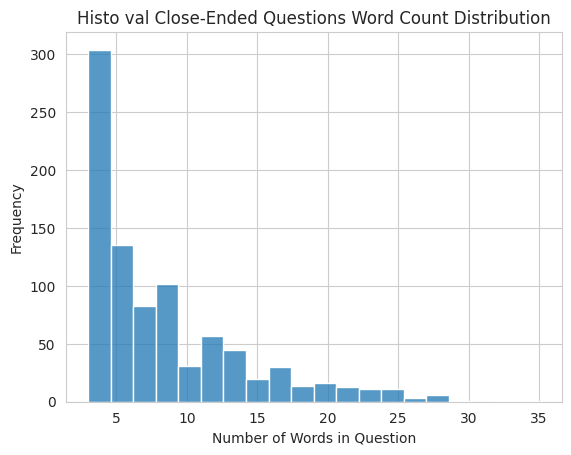

In [28]:
pvqa_histo_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_close_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_close_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


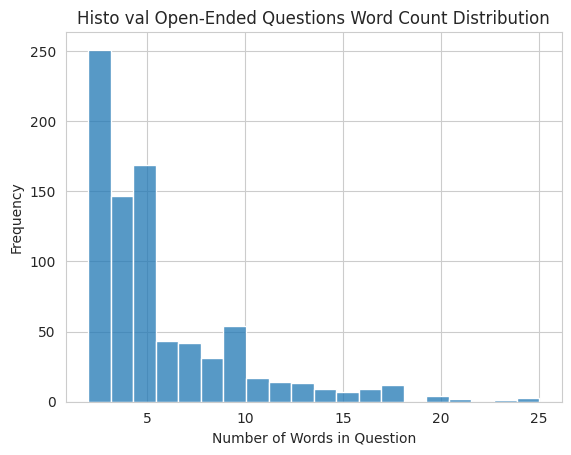

In [29]:
pvqa_histo_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_questions_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

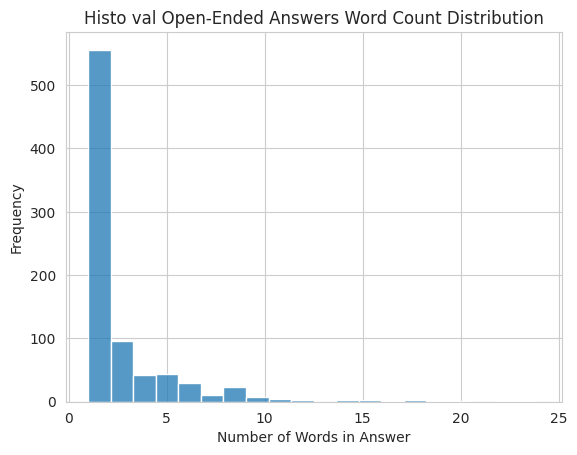

In [30]:
pvqa_histo_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_histo_qas_open_ended]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_answers_words_distrib, bins=20)
plt.title(f'Histo {pvqa_subset} Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()